In [1]:
# Import dependencies

import numpy as np
from tqdm import tqdm
import multiprocessing as mp
import os
from PIL import Image
import rasterio as rio
import matplotlib.pyplot as plt
import glob
import random
from collections import Counter
import pandas as pd


# Patches and their corresponding AIS labels

Ship Patches and AIS data:

In [60]:
# Data path
head_dir = "/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/"

patch_dirs = []

# Walk through the directory tree
for root, dirs, files in os.walk(head_dir):
    # Check if this folder has no subfolders (i.e., it's a leaf folder)
    if not dirs:
        # Check if the current folder itself is named 'ship_patches'
        if os.path.basename(root) == 'ship_patches':
            patch_dirs.append(root)


# Print the results
patch_dirs


['/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222538_HH_1/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222543_HH_2/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222549_HH_3/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222555_HH_4/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222600_HH_5/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_grd_240118_082036_HH/NovaSAR_01_51676_grd_13_240118_082042_HH_2/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_g

In [63]:
# Add Wake Potential column to AIS.csv files:

for p_dirsii in patch_dirs:
    # Walk through the directory and find all .tif files
    for root, dirs, files in os.walk(p_dirsii):
        head_dirii = f"{'/'.join(root.split('/')[:-1])}/"
        AIS_dirii = f"{head_dirii}AIS.csv"
        
        
        AIS_dfii = pd.read_csv(AIS_dirii)
        if ('Wake Potential' in AIS_dfii.columns) == False:
            wake_idxii= np.where(AIS_dfii['SOG'].to_numpy() > 1)[0] # Only consider ships with SOG > 1 knot (to avoid stationary objects)
            AIS_dfii['Wake Potential'] = ""
            AIS_dfii.loc[wake_idxii, 'Wake Potential'] = 1
            AIS_dfii.to_csv(AIS_dirii, index=False)
        
        if ('Wake Quality' in AIS_dfii.columns) == False:
            AIS_dfii['Wake Quality'] = ""
            AIS_dfii.to_csv(AIS_dirii, index=False)


In [64]:
# tif files directories and AIS dataframe:

import re
tif_dir = []
AIS_df  = []
for p_dirsii in patch_dirs:
    tif_dir.append([])  # Add the directory itself to the list
    # Walk through the directory and find all .tif files
    for root, dirs, files in os.walk(p_dirsii):
        head_dirii = f"{'/'.join(root.split('/')[:-1])}/"
        AIS_dirii = f"{head_dirii}AIS.csv"
        AIS_dfii = pd.read_csv(AIS_dirii)     
        AIS_df.append(AIS_dfii)
        
        scene_pathii = head_dirii+[ f for f in os.listdir(head_dirii) if 'corrected' in f ][0]
        AIS_df[-1]['Scene path'] = scene_pathii
        metadata_pathii = scene_pathii[:-22]+'metadata.xml'
        AIS_df[-1]['Metadata path'] = metadata_pathii

        files = sorted(files, key=lambda x: int(re.search(r'patch_(\d+)', x).group(1)))
        for file in files:
            if file.lower().endswith('.tif'):         
                full_pathii = os.path.join( root, file )
                tif_dir[-1].append( full_pathii )

AIS_df  = pd.concat(AIS_df, ignore_index=True)
tif_dir = [item for sublist in tif_dir for item in sublist]
print(f"Found {len(tif_dir)} patches in {len(patch_dirs)} directories.")

Found 3415 patches in 624 directories.


In [65]:
AIS_df['timeframe_dt'] = pd.to_datetime(AIS_df['# Timestamp'], format='mixed',dayfirst=True)
AIS_df = AIS_df.sort_values(by='timeframe_dt', ascending=True).reset_index(drop=True)
AIS_df

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,D,Patch_name,Dist_to_land,Shoreline,Wake Potential,Wake Quality,Scene path,Metadata path,Quality,timeframe_dt
0,22/11/2023 22:25:16,Class A,219001604,56.127645,12.308893,Engaged in fishing,0.0,0.0,216.4,150.0,...,3.0,NovaSAR_01_50023_grd_13_231122_222520_HH_7_pat...,2.375230,inshore,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,2023-11-22 22:25:16
1,22/11/2023 22:25:16,Class A,219004203,56.125950,12.310500,Engaged in fishing,0.0,0.0,146.5,346.0,...,3.0,NovaSAR_01_50023_grd_13_231122_222520_HH_7_pat...,0.895116,inshore,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,2023-11-22 22:25:16
2,22/11/2023 22:25:17,Class B,219002998,56.126862,12.309937,Unknown value,NaN,0.0,358.6,NaN,...,3.0,NovaSAR_01_50023_grd_13_231122_222520_HH_7_pat...,11.712577,inshore,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,2023-11-22 22:25:17
3,22/11/2023 22:25:17,Class B,219005385,56.126588,12.310163,Unknown value,NaN,0.0,156.3,NaN,...,1.0,NovaSAR_01_50023_grd_13_231122_222520_HH_7_pat...,5.432193,inshore,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,2023-11-22 22:25:17
4,22/11/2023 22:25:18,Class A,636023128,56.218730,12.326543,Under way using engine,0.0,13.9,136.2,147.0,...,23.0,NovaSAR_01_50023_grd_13_231122_222520_HH_7_pat...,10025.720191,offshore,1.0,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,2023-11-22 22:25:18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,05/06/2024 22:03:15,Class A,255806462,55.236532,13.896043,Under way using engine,0.0,10.3,276.2,277.0,...,8.0,NovaSAR_01_54685_grd_13_240605_220313_HH_3_pat...,6557.285677,offshore,1.0,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,2024-06-05 22:03:15
3411,05/06/2024 22:03:17,Class A,209864000,55.191575,13.858050,Under way using engine,0.0,13.2,170.3,172.0,...,14.0,NovaSAR_01_54685_grd_13_240605_220313_HH_3_pat...,8984.410382,offshore,1.0,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,2024-06-05 22:03:17
3412,05/06/2024 22:03:17,Class A,230617000,54.985422,13.620405,Under way using engine,2.9,17.5,250.0,250.0,...,22.0,NovaSAR_01_54685_grd_13_240605_220318_HH_4_pat...,1567.210703,offshore,1.0,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,2024-06-05 22:03:17
3413,05/06/2024 22:03:17,Class A,232026551,54.953547,13.567260,Under way using engine,0.0,10.4,252.2,255.0,...,8.0,NovaSAR_01_54685_grd_13_240605_220318_HH_4_pat...,5115.630310,offshore,1.0,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,2024-06-05 22:03:17


In [66]:
# Functions:
from functions import *

def patch_hw_span(lat, lon, heading_angle, h, w, ref_im_path, roll, pass_direction='ASCENDING', antenna_pointing='Left'):
    
    row_ship, col_ship = AIS_row_col_from_lat_lon(lat_AIS = [lat], lon_AIS = [lon], im_path=ref_im_path)
    row_ship, col_ship = row_ship[0], col_ship[0]
    
    print(f"row_ship, col_ship: {row_ship}, {col_ship}, heading_angle: {heading_angle}, roll: {roll}, pass_direction: {pass_direction}, antenna_pointing: {antenna_pointing}")
    
    
    if pass_direction == 'ASCENDING':
        heading_angle = 180-heading_angle  # Ascending => FlipUD
        if heading_angle < 0:
            heading_angle += 360
        if antenna_pointing=="Left":
            heading_angle = 360-heading_angle  # Left-looking Ascending => FlipLR
            roll = -roll  # Adjust roll direction for Left-looking Ascending
    
    if pass_direction == 'DESCENDING':
        if antenna_pointing=="Right":
            heading_angle = 360-heading_angle  # Right-looking Descending => FlipLR
        
    heading_angle -= roll  # Adjust heading angle based on satellite roll angle
    
    if heading_angle < 0:
        heading_angle += 360
    
    buffer_coef = 0.15  # Buffer to ensure ship is within patch
    if heading_angle < 22.5 or heading_angle-360 >= -22.5: # North 
        print("Ship Approximate location in the patch: North Region")     
        row_span = ( row_ship - int(buffer_coef*h), row_ship + 2*h-int(buffer_coef*h) )
        col_span = ( col_ship-w, col_ship+w )
    
    if heading_angle < 45+22.5 and heading_angle >= 22.5: # North-East
        print("Ship Approximate location in the patch: North-East Region")
        row_span = ( row_ship - int(buffer_coef*h), row_ship + 2*h-int(buffer_coef*h) )
        col_span = ( col_ship-2*w + int(buffer_coef*w), col_ship + int(buffer_coef*w) )

    if heading_angle < 2*45+22.5 and heading_angle >= 45+22.5: # East   
        print("Ship Approximate location in the patch: East Region")
        row_span = ( row_ship-h, row_ship+h )
        col_span = ( col_ship-2*w + int(buffer_coef*w), col_ship + int(buffer_coef*w) )

    if heading_angle < 3*45+22.5 and heading_angle >= 2*45+22.5: # South-East 
        print("Ship Approximate location in the patch: South-East Region")
        row_span = ( row_ship-2*h + int(buffer_coef*h), row_ship + int(buffer_coef*h) )
        col_span = ( col_ship-2*w + int(buffer_coef*w), col_ship + int(buffer_coef*w) )

    if heading_angle < 4*45+22.5 and heading_angle >= 3*45+22.5: # South 
        print("Ship Approximate location in the patch: South Region")
        row_span = ( row_ship-2*h + int(buffer_coef*h), row_ship + int(buffer_coef*h) )
        col_span = ( col_ship-w, col_ship+w)

    if heading_angle < 5*45+22.5 and heading_angle >= 4*45+22.5: # South-West   
        print("Ship Approximate location in the patch: South-West Region")
        row_span = ( row_ship-2*h + int(buffer_coef*h), row_ship + int(buffer_coef*h) )
        col_span = ( col_ship - int(buffer_coef*w), col_ship+2*w -int(buffer_coef*w) )

    if heading_angle < 6*45+22.5 and heading_angle >= 5*45+22.5: # West   
        print("Ship Approximate location in the patch: West Region")
        row_span = ( row_ship-h, row_ship+h)
        col_span = ( col_ship - int(buffer_coef*w), col_ship+2*w - int(buffer_coef*w) )

    if heading_angle < 7*45+22.5 and heading_angle >= 6*45+22.5: # North-West   
        print("Ship Approximate location in the patch: North-West Region")
        row_span = ( row_ship - int(buffer_coef*h), row_ship+2*h - int(buffer_coef*h) )
        col_span = ( col_ship - int(buffer_coef*w), col_ship+2*w - int(buffer_coef*w) )
    
    return row_span, col_span
      

def wake_patch(ref_im, ref_im_io, row_span, col_span, export_path_head, export_name, h, w, uint8=False, plt_ptch=False):
    import os
    import rasterio as rio
    from rasterio.windows import Window
    import matplotlib.pyplot as plt
    import shutil
    
    patch_output_dir = f"{export_path_head}/wake_patches"
    if not os.path.exists(patch_output_dir):
        os.makedirs(patch_output_dir)

    if uint8:
        if not os.path.exists(f"{patch_output_dir}_uint8"):
            os.makedirs(f"{patch_output_dir}_uint8")

    row0, col0 = max( row_span[0],0 ), max( col_span[0],0 )
    if row_span[1]>=ref_im.shape[0]:
        row0 = ref_im.shape[0]-2*h
    if col_span[1]>=ref_im.shape[1]:
        col0 = ref_im.shape[1]-2*w
    row1, col1 = min( row0+2*h,ref_im.shape[0] ), min( col0+2*w,ref_im.shape[1] )

    subii = ref_im[row0:row1, col0:col1]

    # Adjust metadata:
    out_meta = ref_im_io.meta.copy()
    out_meta.update({
        "height"   : row1-row0,
        "width"    : col1-col0,
        "transform": ref_im_io.window_transform( Window(col0, row0, col1-col0, row1-row0) ),
        "compress" :'lzw'
    })
            
    out_nameii   = f"{patch_output_dir}/{export_name}_Wake.tif"
    with rio.open(out_nameii, "w", **out_meta) as dest:
        dest.write(subii,1)

        if uint8:
            subii = subii.astype('float32')
            subii -= subii.mean()
            subii /= 5*subii.std()
            subii += 0.5
            subii = (255 * subii).clip(0, 255).astype('uint8')
            
            out_nameii   = f"{patch_output_dir}_uint8/{export_name}_Wake_uint8.tif"
            out_meta.update({
                "dtype": 'uint8',
            })
            with rio.open(out_nameii, "w", **out_meta) as dest:
                dest.write(subii,1)

    if plt_ptch:
        plt.figure()
        plt.imshow(subii, cmap='gray', vmin=0, vmax=1500)
        plt.text(h, w, f"{export_name}", fontsize=10, color='blue', ha='center', va='center')

Ship Wake Extraction:

In [67]:
ship_name     = AIS_df['Ship type'].tolist()
scene_path    = AIS_df['Scene path'].tolist()
metadata_path = AIS_df['Metadata path'].tolist()
ship_SOG      = AIS_df['SOG'].to_numpy()
ship_COG      = AIS_df['COG'].to_numpy()
ship_heading  = AIS_df['Heading'].to_numpy()
wake_idx      = np.where(ship_SOG > 1)[0]
ship_lat      = AIS_df['Latitude'].to_numpy()
ship_lon      = AIS_df['Longitude'].to_numpy()
patch_name    = AIS_df['Patch_name'].tolist()
len(wake_idx)

1409

In [87]:
scene_path[wake_idx[160]]

'/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50588_grd_231211_223819_HH/NovaSAR_01_50588_grd_13_231211_223823_HH_2/image_HH_corrected.tif'

In [82]:
h, w = 512, 512  # Patch half-height and half-width

for idxii in wake_idx[15:21]:
    geoinfoii = geo_info_from_metadata(metadata_path[idxii])
    rollii = float(geoinfoii['PlatformRoll'])
    passii = geoinfoii['Pass_Direction']
    antenna_pointingii = geoinfoii['AntennaPointing']
    print(f"{idxii}: {ship_name[idxii]}, {ship_SOG[idxii]} kn, {scene_path[idxii]}")
    export_nameii = patch_name[idxii]
    print(f"Ship Patch name: {export_nameii}")
    
    if np.isnan(ship_heading[idxii]) == False or np.isnan(ship_COG[idxii]) == False:
        if np.isnan(ship_heading[idxii]) == False:
            heading_angleii = ship_heading[idxii]
        else:
            heading_angleii = ship_COG[idxii]
        
        ref_im_io = rio.open(scene_path[idxii])

        ref_im = ref_im_io.read(1)

        export_path_head = f"{'/'.join(scene_path[idxii].split('/')[:-1])}/"

        row_spanii, col_spanii = patch_hw_span(lat=[ship_lat[idxii]], lon=[ship_lon[idxii]], heading_angle=heading_angleii, h=h, w=w, ref_im_path=scene_path[idxii], roll=rollii, pass_direction=passii, antenna_pointing=antenna_pointingii)
        
        wake_patch(ref_im=ref_im, ref_im_io=ref_im_io, row_span=row_spanii, col_span=col_spanii, export_path_head=export_path_head, export_name=export_nameii, h=h, w=w, uint8=True, plt_ptch=False)
    else:
        print("No heading info available.")

    print("\n")

80: Cargo, 9.5 kn, /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50082_grd_231124_223620_HH/NovaSAR_01_50082_grd_13_231124_223625_HH_2/image_HH_corrected.tif
Ship Patch name: NovaSAR_01_50082_grd_13_231124_223625_HH_2_patch_1_Cargo
row_ship, col_ship: 13858, 7002, heading_angle: 270.0, roll: 19.98, pass_direction: DESCENDING, antenna_pointing: Left
Ship Approximate location in the patch: West Region


81: Cargo, 13.9 kn, /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50082_grd_231124_223620_HH/NovaSAR_01_50082_grd_13_231124_223625_HH_2/image_HH_corrected.tif
Ship Patch name: NovaSAR_01_50082_grd_13_231124_223625_HH_2_patch_2_Cargo
row_ship, col_ship: 13333, 7243, heading_angle: 279.0, roll: 19.98, pass_direction: DESCENDING, antenna_pointing: Left
Ship Approximate location in the patch: West Region


82: Fishing, 12.2 kn, /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50082_grd_231124_223620_HH/NovaSAR_01_50082_grd_13_231124_

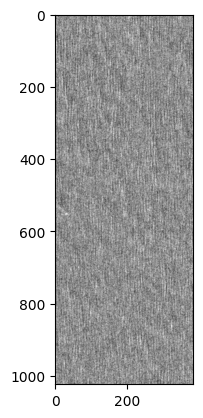

In [ ]:
plt.imshow( 10*np.log10(ref_im[14568:15592, 7520:7904]), cmap='gray' )

Find All Wake Patch Directories:

In [88]:
wake_patch_dirs = []

# Walk through the directory tree
for root, dirs, files in os.walk(head_dir):
    # Check if this folder has no subfolders (i.e., it's a leaf folder)
    if not dirs:
        # Check if the current folder itself is named 'ship_patches'
        if os.path.basename(root) == 'wake_patches':
            wake_patch_dirs.append(root)


# Print the results
wake_patch_dirs


['/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222543_HH_2/wake_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222549_HH_3/wake_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222600_HH_5/wake_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_grd_240118_082036_HH/NovaSAR_01_51676_grd_13_240118_082042_HH_2/wake_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_grd_240118_082036_HH/NovaSAR_01_51676_grd_13_240118_082047_HH_3/wake_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_grd_240118_082036_HH/NovaSAR_01_51676_grd_13_240118_082053_HH_4/wake_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_g

Copy Wake Patches to OneDrive:

In [90]:
# Copy Wake Patches to OneDrive:

import os
import shutil

# Target directory
target_dir = '/mnt/c/Users/vn25612/OneDrive - University of Bristol/NovaSARNet/'

# Create target directory if it doesn't exist
os.makedirs(target_dir, exist_ok=True)

# Copy files from each source directory to the target directory
for wake_patch_dirii in wake_patch_dirs:
    # Copy Wake Patchces:
    patch_target_dirii = f"{target_dir}{'/'.join(wake_patch_dirii.split('/')[-4:])}"
    os.makedirs(patch_target_dirii, exist_ok=True)
    for filenameii in os.listdir(wake_patch_dirii):
        src_fileii = os.path.join(wake_patch_dirii, filenameii)
        if os.path.isfile(src_fileii):
            shutil.copy2(src_fileii, patch_target_dirii)
    
    # Copy Wake Patchces UINT8:
    patch_target_dirii = f"{target_dir}{'/'.join(wake_patch_dirii.split('/')[-4:])}_uint8"
    os.makedirs(patch_target_dirii, exist_ok=True)
    patch_diru8ii = f"{wake_patch_dirii}_uint8"
    for filenameii in os.listdir(patch_diru8ii):
        src_fileii = os.path.join(patch_diru8ii, filenameii)
        if os.path.isfile(src_fileii):
            shutil.copy2(src_fileii, patch_target_dirii)
    
    
    # Copy AIS.csv:
    ais_target_dirii = f"{target_dir}{'/'.join(wake_patch_dirii.split('/')[-4:-1])}"
    shutil.copy2(f"{'/'.join(wake_patch_dirii.split('/')[:-1])}/AIS.csv", ais_target_dirii)